In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-03-06 10:31:11--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-03-06 10:31:11--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-03-06 10:31:11--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

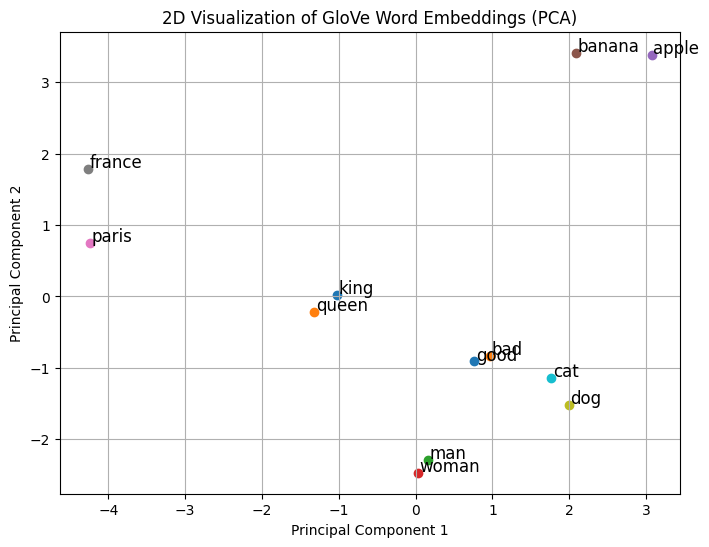

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load GloVe embeddings
glove_path = "/content/glove.6B.100d.txt"
embedding_index = {}

with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

# Select words to visualize
words_to_visualize = ["king", "queen", "man", "woman", "apple", "banana", "paris", "france", "dog", "cat","good","bad"]
vectors = np.array([embedding_index[word] for word in words_to_visualize])

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)

# Plot the words
plt.figure(figsize=(8, 6))
for i, word in enumerate(words_to_visualize):
    plt.scatter(reduced_vectors[i, 0], reduced_vectors[i, 1], marker='o')
    plt.text(reduced_vectors[i, 0] + 0.02, reduced_vectors[i, 1] + 0.02, word, fontsize=12)

plt.title("2D Visualization of GloVe Word Embeddings (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.regularizers import l2
import tensorflow_datasets as tfds
import numpy as np

# Load Yelp Polarity dataset
dataset, info = tfds.load('yelp_polarity_reviews', with_info=True, as_supervised=True)
train_data, test_data = dataset['train'], dataset['test']

# Prepare the data
vocab_size = 50000  # Limit vocabulary to top 50,000 words
max_length = 200    # Maximum review length (truncation/padding)

# Tokenizer to convert text to sequences
tokenizer = keras.preprocessing.text.Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts([text.numpy().decode('utf-8') for text, _ in train_data])

# Convert text data to sequences and pad them
def preprocess_dataset(dataset):
    texts, labels = [], []
    for text, label in dataset:
        texts.append(text.numpy().decode('utf-8'))
        labels.append(label.numpy())
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    return padded_sequences, np.array(labels)

# Preprocess training and testing data
tr_x, tr_y = preprocess_dataset(train_data)
te_x, te_y = preprocess_dataset(test_data)



Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/560000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/yelp_polarity_reviews/incomplete.AENS7X_0.2.0/yelp_polarity_reviews-train.…

Generating test examples...:   0%|          | 0/38000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/yelp_polarity_reviews/incomplete.AENS7X_0.2.0/yelp_polarity_reviews-test.t…

Dataset yelp_polarity_reviews downloaded and prepared to /root/tensorflow_datasets/yelp_polarity_reviews/0.2.0. Subsequent calls will reuse this data.


In [ ]:
# Load GloVe 6B embeddings
glove_path = "/content/glove.6B.100d.txt"  # Update with the correct path
embedding_dim = 100  # Choose dimension (50d, 100d, 200d, or 300d)

# Create a dictionary mapping words to vectors
embeddings_index = {}
with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

# Create an embedding matrix for the tokenizer’s vocabulary
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector



In [ ]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model('NLPModel.h5')


In [ ]:
def predict_sentiment(model, text, tokenizer, max_length=200):
    # Convert text to sequence using the tokenizer
    sequence = tokenizer.texts_to_sequences([text])

    # Pad the sequence to the fixed length
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Get prediction probability
    prediction = model.predict(padded_sequence)[0][0]

    # Classify sentiment
    sentiment = "Positive" if prediction > 0.5 else "Negative"

    # Confidence score
    confidence = prediction if sentiment == "Positive" else 1 - prediction

    return sentiment, confidence


In [ ]:
#test_loss, test_acc = model.evaluate(te_x, te_y)
#print(f"Test Accuracy: {test_acc:.4f} (identical to original model)")

# Manual verification
sample_text = "The movie was great and the acting was whopping"
sentiment, confidence = predict_sentiment(model, sample_text, tokenizer)
print(f"\nSample Prediction: {sentiment} with confidence {confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Sample Prediction: Negative with confidence 0.7644


# Function: predict_proba
This function predicts the probability of a given text being positive or negative using a trained model.

How It Works:

1.   Converts the input text into a sequence using the tokenizer.
2.   Pads or truncates the sequence to a fixed max_length (default: 200).
3.   Passes the processed sequence to the model for prediction.
4.   Computes probabilities for positive and negative sentiments.







In [ ]:
def predict_proba(model, text, tokenizer, max_length=200):
    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')

    # Get raw probabilities (output of the sigmoid)
    prob_positive = model.predict(padded_sequence)[0][0]
    prob_negative = 1 - prob_positive
    return {"Positive": prob_positive, "Negative": prob_negative}

In [ ]:
!wget https://raw.githubusercontent.com/nmrksic/counter-fitting/master/word_vectors/counter-fitted-vectors.txt.zip
!unzip counter-fitted-vectors.txt.zip

counter_embeddings = {}
with open("counter-fitted-vectors.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        counter_embeddings[word] = vector

--2025-03-06 10:48:02--  https://raw.githubusercontent.com/nmrksic/counter-fitting/master/word_vectors/counter-fitted-vectors.txt.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65009363 (62M) [application/zip]
Saving to: ‘counter-fitted-vectors.txt.zip’

counter-fitted-vect 100%[===================>]  62.00M   293MB/s    in 0.2s    

2025-03-06 10:48:03 (293 MB/s) - ‘counter-fitted-vectors.txt.zip’ saved [65009363/65009363]

Archive:  counter-fitted-vectors.txt.zip
  inflating: counter-fitted-vectors.txt  


In [ ]:
import tensorflow_hub as hub

# Load USE from TensorFlow Hub
use_embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

def semantic_similarity(text1, text2):
    embeddings = use_embed([text1, text2])
    return np.inner(embeddings[0], embeddings[1])

# Function: compute_importance
This function evaluates the importance of words in a sentence for a sentiment classification model by measuring their impact on the model's predictions.

## How It Works:


1.   Tokenizes the input sentence using SpaCy.
2.   Identifies important words by filtering out stopwords.
3.   Computes the original sentiment probabilities using predict_proba().
4.   Iteratively removes each important word and observes how the model's prediction changes.
5.   Assigns an importance score based on the change in probability.
6.   Returns a sorted list of words and their importance scores.

# Output:
A list of tuples ((position, word), importance_score), ranked from most to least important.

This helps interpret model decisions by identifying key words that influence sentiment classification.

In [ ]:
import spacy
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words("english"))

def compute_importance(sentence, model, tokenizer):
    doc = nlp(sentence)
    tokens = [token.text for token in doc]
    # Identify important words and their positions
    important_words = [
        (i, token.text)
        for i, token in enumerate(doc)
        if token.text.lower() not in stop_words
    ]

    original_probs = predict_proba(model, sentence, tokenizer)
    original_label = max(original_probs, key=original_probs.get)
    importance_scores = {}

    for pos, word in important_words:
        # Remove word from original tokens
        perturbed_tokens = tokens[:pos] + tokens[pos+1:]
        perturbed_sentence = " ".join(perturbed_tokens)

        perturbed_probs = predict_proba(model, perturbed_sentence, tokenizer)
        perturbed_label = max(perturbed_probs, key=perturbed_probs.get)  # Define perturbed_label

        if perturbed_label == original_label:
            score = original_probs[original_label] - perturbed_probs[original_label]
        else:
            score = (original_probs[original_label] - perturbed_probs[original_label]) + \
                    (perturbed_probs[perturbed_label] - original_probs[perturbed_label])

        importance_scores[(pos, word)] = score

    # Sort by score and return
    return sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Function: get_synonyms
This function finds synonyms for a given word based on vector similarity while ensuring they match the original word's part of speech (POS).

## How It Works:


1.   Retrieves the word's vector representation from counter_embeddings.
2.   Iterates through other words in counter_embeddings and computes cosine similarity with the target word.
3.   Ensures that the candidate words match the original part of speech (POS).
4.   Filters out words below a similarity threshold (sim_threshold, default: 0.7).
5.  Returns the top N most similar words (default: 50), sorted by similarity.

# Output:
A list of tuples ((position, word), importance_score), ranked from most to least important.

A list of synonyms ranked by similarity, which can be used for text augmentation or model interpretability.

In [ ]:
from collections import defaultdict
import numpy as np

def get_synonyms(word, original_pos, top_n=50, sim_threshold=0.7):
    if word not in counter_embeddings:
        return []

    target_vector = counter_embeddings[word]
    similarities = []

    for candidate, vec in counter_embeddings.items():
        if candidate == word:
            continue

        # POS check using original context POS
        candidate_doc = nlp(candidate)
        if len(candidate_doc) != 1 or candidate_doc[0].pos_ != original_pos:
            continue

        # Cosine similarity
        sim = np.dot(target_vector, vec) / (np.linalg.norm(target_vector) * np.linalg.norm(vec))
        if sim >= sim_threshold:
            similarities.append((candidate, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return [word for word, _ in similarities[:top_n]]

In [ ]:
def textfooler_attack(sentence, model, tokenizer, max_perturb=0.2, epsilon=0.7):
    doc = nlp(sentence)
    tokens = [token.text for token in doc]
    original_probs = predict_proba(model, sentence, tokenizer)
    original_label = max(original_probs, key=original_probs.get)

    # Get sorted important words with positions
    importance = compute_importance(sentence, model, tokenizer)
    allowed_changes = int(len(tokens) * max_perturb)
    perturb_count = 0

    working_tokens = tokens.copy()

    for (pos, word), _ in importance:
        if perturb_count >= allowed_changes:
            break

        # Get POS from original sentence context
        original_pos = doc[pos].pos_
        synonyms = get_synonyms(word, original_pos)

        for synonym in synonyms:
            # Replace at specific position
            new_tokens = working_tokens.copy()
            new_tokens[pos] = synonym
            new_sentence = " ".join(new_tokens)

            # Check semantic similarity
            if semantic_similarity(sentence, new_sentence) < epsilon:
                continue

            # Check prediction
            new_probs = predict_proba(model, new_sentence, tokenizer)
            new_label = max(new_probs, key=new_probs.get)

            if new_label != original_label:
                return new_sentence  # Return on first success

        perturb_count += 1

    return None  # Attack failed

In [ ]:
  # Sample attack with sentiment analysis
  sentence = "The movie was great and the acting was amazing"

  # Get original sentiment
  original_sentiment, original_conf = predict_sentiment(model, sentence, tokenizer)

  # Generate adversarial example
  adversarial = textfooler_attack(sentence, model, tokenizer)

  # Print results
  print(f"\nOriginal: {sentence}")
  print(f"Original Sentiment: {original_sentiment} (Confidence: {original_conf:.2f})")

  if adversarial:
      # Get adversarial sentiment
      adv_sentiment, adv_conf = predict_sentiment(model, adversarial, tokenizer)
      success = original_sentiment != adv_sentiment

      print(f"\nAdversarial: {adversarial}")
      print(f"Adversarial Sentiment: {adv_sentiment} (Confidence: {adv_conf:.2f})")
      print(f"Attack Successful? {'YES' if success else 'NO'}")
  else:
      print("\nAttack failed - no valid adversarial example found")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━